Backpropagation plus gradient desent for linear classification of random data. (email classification spam | not spam).

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
import pandas as pd

In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
    print(f"Uploaded file: {filename}")
    # Try reading with 'latin1' encoding to handle common character issues
    try:
        df = pd.read_csv(filename, encoding='latin1')
        print(df.head())
    except UnicodeDecodeError:
        print(f"UnicodeDecodeError: Could not decode {filename} with 'latin1' encoding. Trying 'cp1252'.")
        try:
            df = pd.read_csv(filename, encoding='cp1252')
            print(df.head())
        except Exception as e:
            print(f"Failed to read {filename} with both 'latin1' and 'cp1252' encodings: {e}")

Saving spam_or_not_spam.csv to spam_or_not_spam.csv
Uploaded file: spam_or_not_spam.csv
                                               email  label
0   date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...      0
1  martin a posted tassos papadopoulos the greek ...      0
2  man threatens explosion in moscow thursday aug...      0
3  klez the virus that won t die already the most...      0
4   in adding cream to spaghetti carbonara which ...      0


In [ ]:
display(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   email   2999 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


None

In [ ]:
# Remove rows where the 'label' column has missing values
df_cleaned = df.dropna(subset=['label']).copy()

print("DataFrame after removing rows with missing 'label' values:")
display(df_cleaned.info())

DataFrame after removing rows with missing 'label' values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   email   2999 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


None

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Convert email text into TF-IDF features
X_tfidf = vectorizer.fit_transform(df_cleaned['email'])

# X will be the TF-IDF features
X = X_tfidf

# Y will be the label column
Y = df_cleaned['label']

print("Shape of X (features):", X.shape)
print("Shape of Y (target):", Y.shape)

Shape of X (features): (3000, 33737)
Shape of Y (target): (3000,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the single neuron model
model = Sequential([
    # The input shape should match the number of features in X_tfidf
    Dense(1, activation='sigmoid', input_shape=(X_tfidf.shape[1],))
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │        33,738 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,738 (131.79 KB)

 Trainable params: 33,738 (131.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
# Using an 80/20 split (test_size=0.2) and a random_state for reproducibility
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (2400, 33737)
Shape of X_test: (600, 33737)
Shape of Y_train: (2400,)
Shape of Y_test: (600,)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Ensure no NaN values are present in the 'email' column before vectorization
# Filling NaNs with an empty string is a common and safe practice for text data.
df_cleaned['email'] = df_cleaned['email'].fillna('')

# Fit and transform the 'email' column to get the TF-IDF matrix
X_tfidf = tfidf_vectorizer.fit_transform(df_cleaned['email'])

print("Shape of the TF-IDF matrix:", X_tfidf.shape)
print("Number of features (unique words/tokens):", len(tfidf_vectorizer.get_feature_names_out()))

Shape of the TF-IDF matrix: (3000, 33737)
Number of features (unique words/tokens): 33737


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

learning_rates = [0.1, 0.01, 0.001]
histories = {}

for lr in learning_rates:
    model = Sequential([
        Input(shape=(X.shape[1],)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, Y_train,
        validation_data=(X_test, Y_test),
        epochs=10,
        batch_size=32,
        verbose=0
    )

    histories[lr] = history

In [ ]:
# Train the model
history = model.fit(
    X_train,
    Y_train,
    epochs=10,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_data=(X_test, Y_test) # Monitor performance on the test set during training
)

print("\nModel training complete!")

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9163 - loss: 0.2634 - val_accuracy: 0.9150 - val_loss: 0.2671
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9260 - loss: 0.2400 - val_accuracy: 0.9300 - val_loss: 0.2540
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9388 - loss: 0.2395 - val_accuracy: 0.9367 - val_loss: 0.2418
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9490 - loss: 0.2232 - val_accuracy: 0.9433 - val_loss: 0.2306
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9601 - loss: 0.1991 - val_accuracy: 0.9483 - val_loss: 0.2203
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9620 - loss: 0.1997 - val_accuracy: 0.9483 - val_loss: 0.2107
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9690 - loss: 0.1829 - val_accuracy: 0.9517 - val_loss: 0.2018
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9703 - loss: 0.1765 - val_accuracy: 0.9550 - val

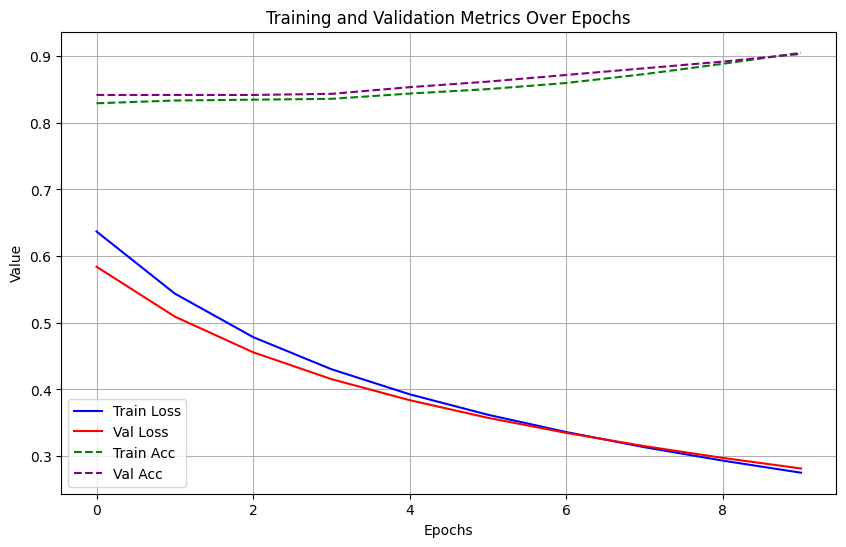

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Train Loss (solid)
plt.plot(history.history['loss'], linestyle='-', color='blue', label='Train Loss')

# Validation Loss (solid)
plt.plot(history.history['val_loss'], linestyle='-', color='red', label='Val Loss')

# Train Accuracy (dashed)
plt.plot(history.history['accuracy'], linestyle='--', color='green', label='Train Acc')

# Validation Accuracy (dashed)
plt.plot(history.history['val_accuracy'], linestyle='--', color='purple', label='Val Acc')

plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.title("Training and Validation Metrics Over Epochs")
plt.grid(True)
plt.show()